In [91]:
import numpy as np
from matplotlib import pyplot as plt
import torch

In [92]:
import torch.nn.functional as F


def resize_tensor(tensor, height, width):
    """Resize [H,W], [C,H,W], or [B,C,H,W] tensor."""

    original_ndim = tensor.ndim

    if original_ndim == 2:
        tensor = tensor.unsqueeze(0).unsqueeze(0)
    elif original_ndim == 3:
        tensor = tensor.unsqueeze(0)
    elif original_ndim != 4:
        raise ValueError("Tensor must have 2, 3, or 4 dimensions.")

    tensor = F.interpolate(
        tensor.float(),
        size=(height, width),
        mode="bilinear",
        align_corners=False,
    )

    if original_ndim == 2:
        return tensor.squeeze(0).squeeze(0)

    if original_ndim == 3:
        return tensor.squeeze(0)

    return tensor

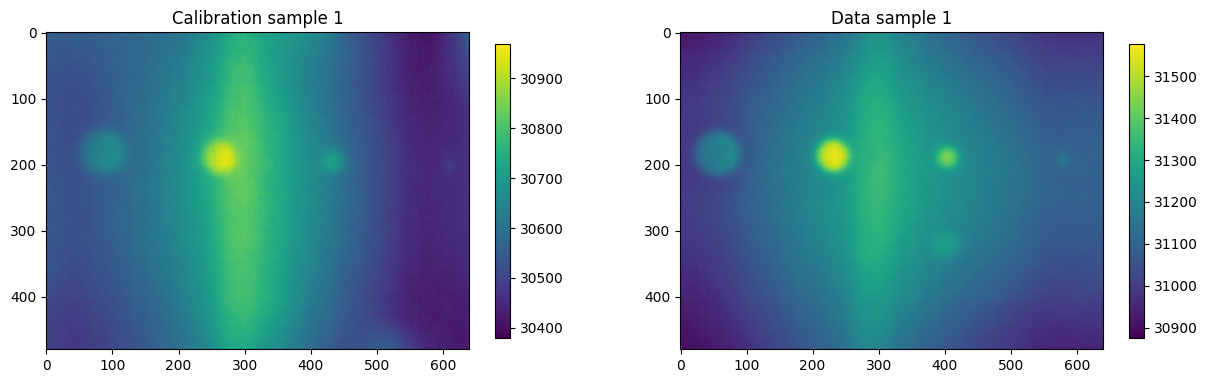

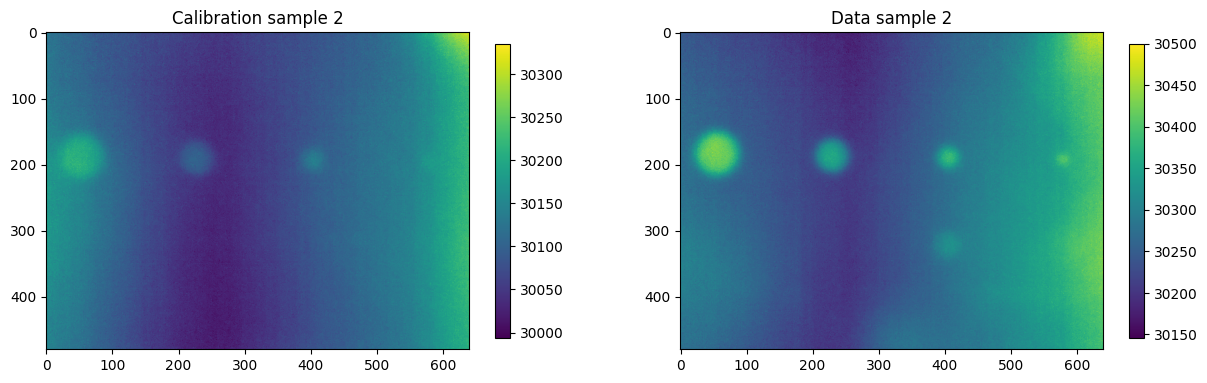

In [23]:
frame=250
shrink_size=0.7
plt.figure(figsize=(15,12))
plt.subplot(2,2,1)
plt.imshow(calib_4['data'][frame])
plt.title('Calibration sample 1')
plt.colorbar(shrink=shrink_size)
plt.subplot(2,2,2)
plt.imshow(data_4['data'][frame])
plt.title('Data sample 1')
plt.colorbar(shrink=shrink_size)

plt.figure(figsize=(15,12))
plt.subplot(2,2,3)
plt.imshow(calib_6['data'][frame])
plt.title('Calibration sample 2')
plt.colorbar(shrink=shrink_size)
plt.subplot(2,2,4)
plt.imshow(data_6['data'][frame])
plt.title('Data sample 2')
plt.colorbar(shrink=shrink_size)

In [93]:
from data.data_operators import BScanDepthDataset,ComposeBScanTransforms
from networks.Unets import BnetSmallKernel
from torch.utils.data import DataLoader
from helper_functions.helper_functions import *
from tqdm import tqdm

In [94]:
device = 'cuda'
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [99]:
pin_memory = True
THICKNESS_MM = 3.5  # sample thickness for our sample we have 3.5


model_path = '/home/jaworskj/projects/thermal_B_scan/No_noise_in_validation_we_reduced_noise_to_proper_limit_no_projection_H_C/Bnet_Projection/best_model_clean.pth'

data = '/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Data_6/Data_6_rb/data_bscans'
depth='/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Data_6/Data_6_rb/data_masks'
normalization_path="/home/jaworskj/projects/thermal_B_scan/normalization_params_heating_and_cooling.npz"

model=BnetSmallKernel().to(device)

state_dict=torch.load(model_path)
model.load_state_dict(state_dict)
model.eval()

projection_mode=None # ---------------------------- Projection modes--------------------------------------
cooling_phase=False
derivative_mode=None

val_dataset = BScanDepthDataset(
    bscan_dir=data,
    depth_dir=depth,
    transform=None,
    normalization_path=normalization_path,
    derivative_mode=derivative_mode,
    projection_mode=projection_mode,
    cooling_phase=cooling_phase
)

# -------------------------
# Loaders
# -------------------------

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=24,
    pin_memory=pin_memory
)

In [100]:
pred_all = []
mask_all = []


with torch.no_grad():
    for X, mask in tqdm(val_loader):
        X = X.to(device)
        mask = mask.to(device)

        pred = model(X)

        pred_all.append(pred.cpu())
        mask_all.append(mask.cpu())

pred_all = torch.cat(pred_all, dim=0)
mask_all = torch.cat(mask_all, dim=0)

100%|██████████| 30/30 [00:06<00:00,  4.35it/s]


In [101]:
pred_all.size()

torch.Size([480, 512])

In [102]:
data_6=np.load('/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Data_6/Data_6_rb/2026_06_16_CFRP_FBH_T2_5s_T3_30s_6_complete.npz',allow_pickle=True)
data_6['data'].shape

(1759, 480, 640)

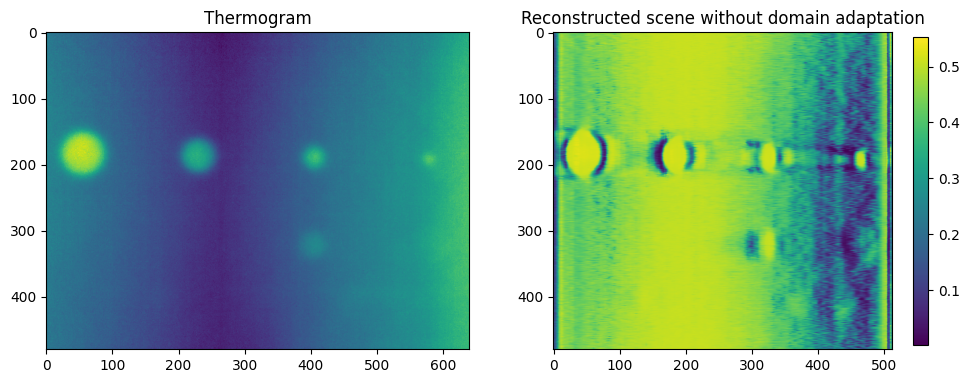

In [103]:
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
plt.imshow(data_6['data'][250])
plt.title('Thermogram')

plt.subplot(1,2,2)
plt.imshow(pred_all)
plt.title('Reconstructed scene without domain adaptation')
plt.colorbar(shrink=0.4)

In [105]:
calibration_dataset = BScanDepthDataset(
    bscan_dir="/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Calibration_6/Calibration_6_rb/data_bscans",
    depth_dir="/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Calibration_6/Calibration_6_rb/data_masks",
    transform=None,
    normalization_path=normalization_path,
    derivative_mode=derivative_mode,
    projection_mode=projection_mode,
    cooling_phase=cooling_phase,
    cooling_frame=0
)

In [106]:
import torch.nn as nn
import torch.optim as optim
import os

In [107]:
train_loader = DataLoader(
    calibration_dataset,
    batch_size=16,
    shuffle=True,   
)

In [108]:
criterion = nn.MSELoss()

# Optional: stable training if you see spikes
GRAD_CLIP_NORM = 1.0  # set e.g. 1.0 if needed

# -------------------------
# Training config
# -------------------------
num_epochs = 20
lr=1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)

In [109]:
main_path = "/home/jaworskj/projects/thermal_B_scan/domain_calibration_data_6"
os.makedirs(main_path, exist_ok=True)

In [110]:
train_log = []
for epoch in tqdm(range(num_epochs), desc=f"epochs", leave=False):
        model.train()
        running_loss = 0.0

        for bscan, depth in tqdm(
            train_loader,
            desc=f"| Epoch {epoch+1} Train",
            leave=False
        ):
            bscan = bscan.to(device, non_blocking=True)
            depth = depth.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            output = model(bscan)
            loss = criterion(output, depth)

            loss.backward()

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

            optimizer.step()

            running_loss += loss.item() * bscan.size(0)

        train_epoch_loss = running_loss / len(train_loader.dataset)
        train_log.append(train_epoch_loss)

        last_path = os.path.join(main_path, f"model_iter_{epoch+1}.pth")
        torch.save(model.state_dict(), last_path)
        torch.save(train_log, os.path.join(main_path, "train_log.pt"))

In [111]:
pred_bfeore=pred_all

Text(0.5, 0, 'Epochs')

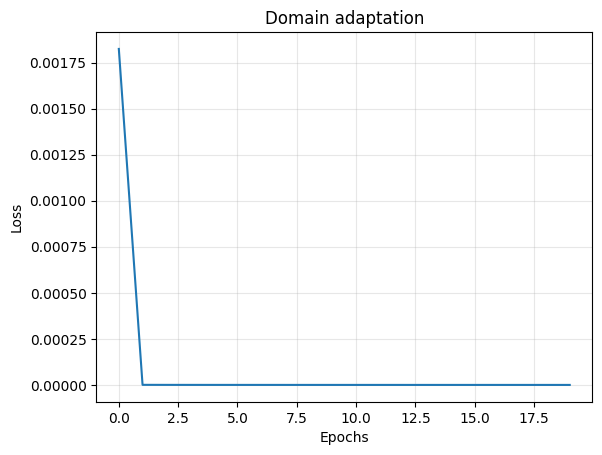

In [112]:
train_log=torch.load("/home/jaworskj/projects/thermal_B_scan/domain_calibration_data_6/train_log.pt")
plt.plot(train_log)
plt.grid(alpha=0.3)
plt.title('Domain adaptation')
plt.ylabel('Loss')
plt.xlabel('Epochs')

In [113]:
model_path='/home/jaworskj/projects/thermal_B_scan/domain_calibration_data_6/model_iter_1.pth'
state_dict=torch.load(model_path)
model.load_state_dict(state_dict)
model.eval()

BnetSmallKernel(
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): 

In [114]:
model.eval()
pred_all = []
mask_all = []


with torch.no_grad():
    for X, mask in tqdm(val_loader):
        X = X.to(device)
        mask = mask.to(device)

        pred = model(X)

        pred_all.append(pred.cpu())
        mask_all.append(mask.cpu())

pred_all = torch.cat(pred_all, dim=0)
mask_all = torch.cat(mask_all, dim=0)

100%|██████████| 30/30 [00:06<00:00,  4.41it/s]


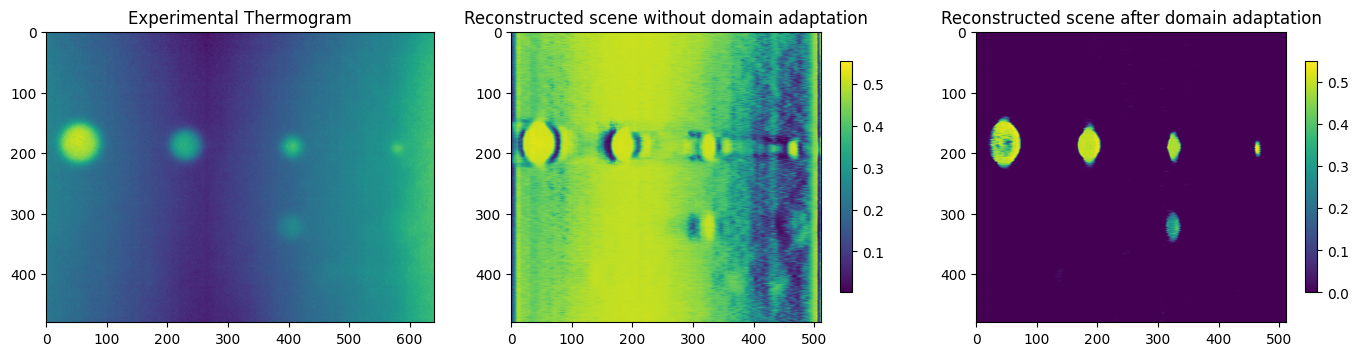

In [115]:
plt.figure(figsize=(17,15))
plt.subplot(1,3,1)
plt.imshow(data_6['data'][250])
plt.title('Experimental Thermogram')

plt.subplot(1,3,2)
plt.imshow(pred_bfeore)
plt.title('Reconstructed scene without domain adaptation')
plt.colorbar(shrink=0.2)

plt.subplot(1,3,3)
plt.imshow(pred_all)
plt.title('Reconstructed scene after domain adaptation')
plt.colorbar(shrink=0.2)

In [116]:
data = '/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Data_6/Data_6_rb/data_bscans_column'
depth='/home/jaworskj/projects/thermal_B_scan/2026_06_16_badania_CFRP/Data_6/Data_6_rb/data_masks_column'

val_dataset = BScanDepthDataset(
    bscan_dir=data,
    depth_dir=depth,
    transform=None,
    normalization_path=normalization_path,
    derivative_mode=derivative_mode,
    projection_mode=projection_mode,
    cooling_phase=cooling_phase
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=24,
    pin_memory=pin_memory
)

In [117]:
pred_row=pred_all

In [118]:
model.eval()
pred_all = []
mask_all = []


with torch.no_grad():
    for X, mask in tqdm(val_loader):
        X = X.to(device)
        mask = mask.to(device)

        pred = model(X)

        pred_all.append(pred.cpu())
        mask_all.append(mask.cpu())

pred_all = torch.cat(pred_all, dim=0)
mask_all = torch.cat(mask_all, dim=0)

100%|██████████| 40/40 [00:09<00:00,  4.38it/s]


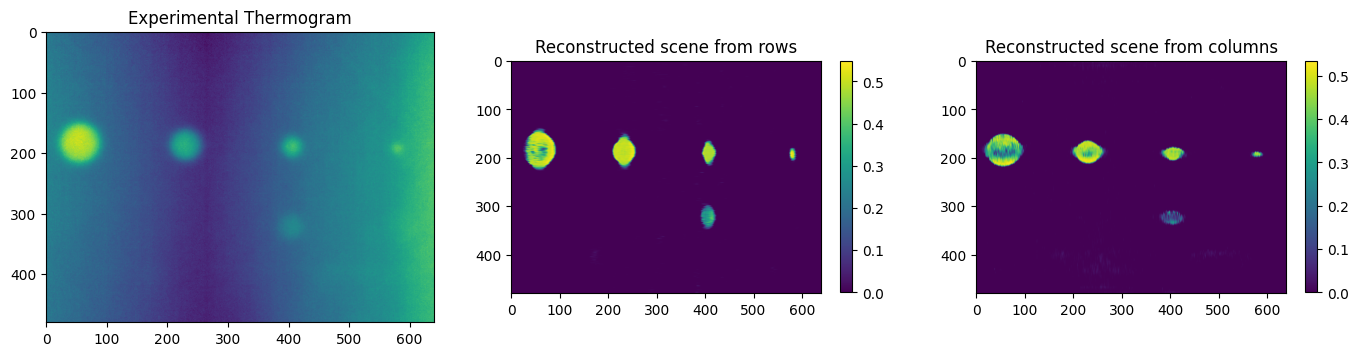

In [119]:
plt.figure(figsize=(17,15))
plt.subplot(1,3,1)
plt.imshow(data_6['data'][250])
plt.title('Experimental Thermogram')

plt.subplot(1,3,2)
plt.imshow(resize_tensor(pred_row,480,640))
plt.title('Reconstructed scene from rows')
plt.colorbar(shrink=0.2)

plt.subplot(1,3,3)
plt.imshow(resize_tensor(torch.flip(pred_all,dims=[-1]).rot90(),480,640))
plt.title('Reconstructed scene from columns')
plt.colorbar(shrink=0.2)

In [120]:
pred_row=resize_tensor(pred_row,480,640)
pred_column=resize_tensor(torch.flip(pred_all,dims=[-1]).rot90(),480,640)


In [121]:
torch.save(pred_row,'pred_row_data_6.pt')
torch.save(pred_column,'pred_column_data_6.pt')

Text(0.5, 1.0, 'Added ande averaged row and column prediction')

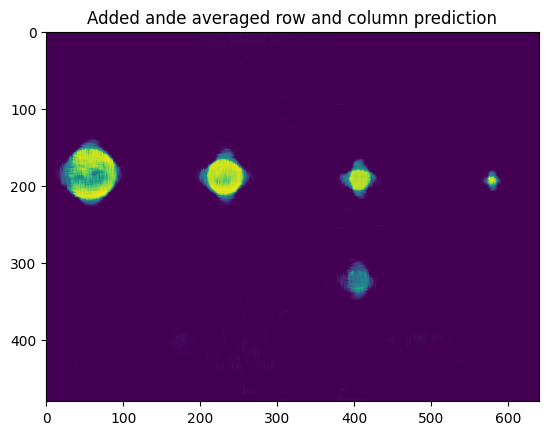

In [122]:
plt.imshow((pred_row+pred_column)/2)
plt.title('Added ande averaged row and column prediction')

In [123]:
def fuse_predictions(pred_row, pred_column, threshold_ratio=0.05):
    if pred_row.shape != pred_column.shape:
        raise ValueError("Predictions must have the same shape.")

    average = (pred_row + pred_column) / 2

    # Ignore very small prediction values.
    threshold = threshold_ratio * torch.maximum(
        pred_row.max(),
        pred_column.max(),
    )

    # A region must appear in both predictions.
    common_region = (
        (pred_row > threshold)
        & (pred_column > threshold)
    )

    fused = torch.where(
        common_region,
        average,
        torch.zeros_like(average),
    )

    return fused

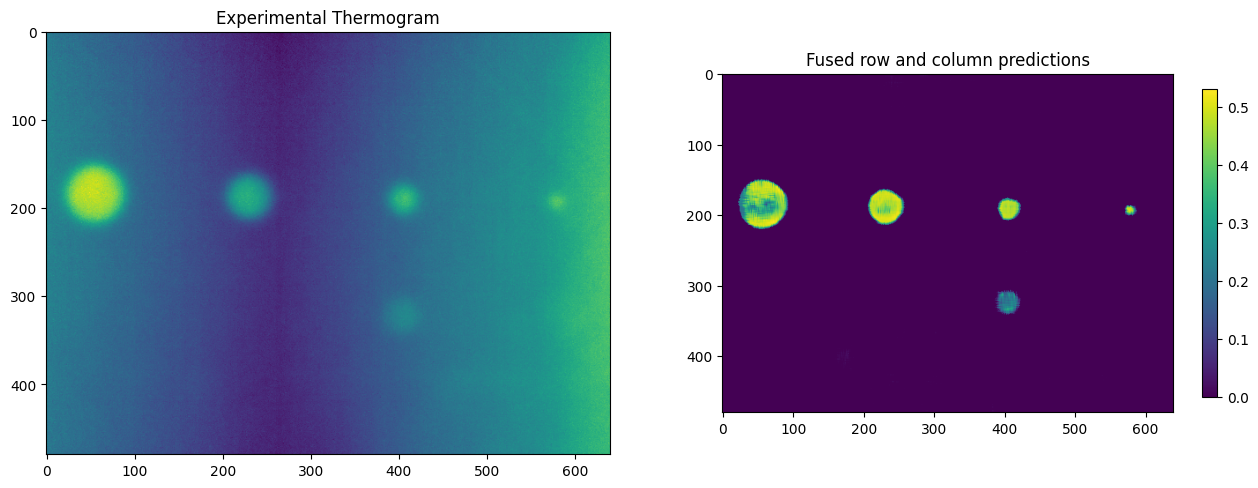

In [126]:
fused = fuse_predictions(
    pred_row,
    pred_column,
    threshold_ratio=0.005,
)

plt.figure(figsize=(16,10))
plt.subplot(1,2,1)
plt.imshow(data_6['data'][250])
plt.title('Experimental Thermogram')

plt.subplot(1,2,2)
plt.imshow(fused.detach().cpu(), cmap="viridis")
plt.colorbar(shrink=0.4)
plt.title('Fused row and column predictions')
plt.show()

In [127]:
torch.save(fused,'fused_data_6.pt')

Text(0, 0.5, 'Predicted normalized depth')

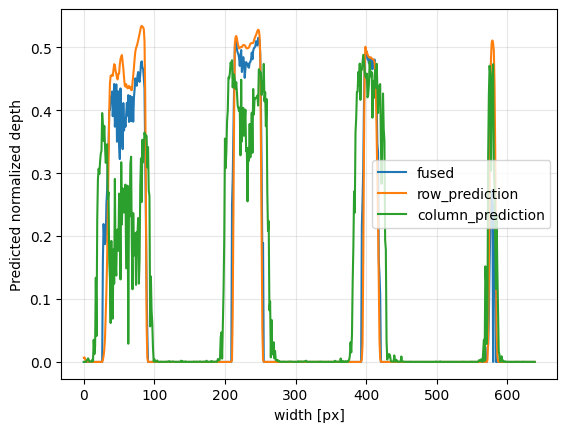

In [130]:
plt.plot(fused[200,:],label='fused')
plt.plot(pred_row[200,:],label='row_prediction')
plt.plot(pred_column[190,:],label='column_prediction')
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel('width [px]')
plt.ylabel('Predicted normalized depth')


Text(0, 0.5, 'Predicted normalized depth')

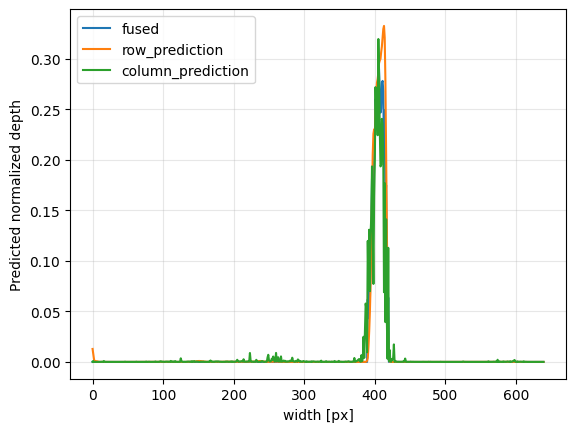

In [131]:
plt.plot(fused[335,:],label='fused')
plt.plot(pred_row[335,:],label='row_prediction')
plt.plot(pred_column[335,:],label='column_prediction')
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel('width [px]')
plt.ylabel('Predicted normalized depth')